In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("omg.csv")

In [9]:
df

,stateEstimate.x,stateEstimate.y,stateEstimate.z,stateEstimate.vx,stateEstimate.vy,stateEstimate.vz
0,-0.317622,-0.376501,0.026477,0.000033,-0.002970,0.000507
1,-0.317752,-0.376235,0.026463,-0.000529,-0.001845,0.000394
2,-0.317814,-0.376187,0.025999,-0.000554,-0.000783,-0.001952
3,-0.317843,-0.376242,0.025993,-0.000600,-0.000853,-0.001742
4,-0.318139,-0.376342,0.025938,-0.002287,-0.001078,-0.001802
...,...,...,...,...,...,...
6751,-0.016439,-0.144900,0.371499,0.323020,-0.400551,0.009566
6752,-0.013751,-0.149403,0.371157,0.322785,-0.404882,0.008694
6753,-0.011144,-0.153819,0.372564,0.322712,-0.408480,0.022734
6754,-0.008443,-0.158226,0.372457,0.322542,-0.411370,0.023924


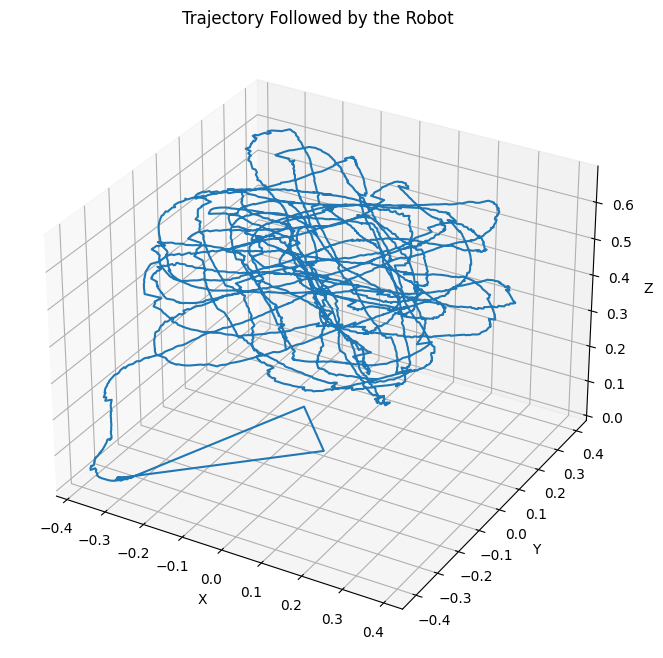

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming your dataframe is named 'df'

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotting the trajectory
ax.plot(df['stateEstimate.x'], df['stateEstimate.y'], df['stateEstimate.z'])

# Labeling the axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Showing the plot
plt.title('Trajectory Followed by the Robot')
plt.show()


In [11]:
df.to_numpy()

array([[-3.17622453e-01, -3.76501054e-01,  2.64766961e-02,
         3.28808383e-05, -2.96954415e-03,  5.06641518e-04],
       [-3.17751557e-01, -3.76234859e-01,  2.64634546e-02,
        -5.29238489e-04, -1.84513454e-03,  3.94387549e-04],
       [-3.17813694e-01, -3.76186609e-01,  2.59987433e-02,
        -5.54273138e-04, -7.82681163e-04, -1.95233058e-03],
       ...,
       [-1.11437254e-02, -1.53818533e-01,  3.72564435e-01,
         3.22712094e-01, -4.08480287e-01,  2.27335002e-02],
       [-8.44316371e-03, -1.58226043e-01,  3.72457147e-01,
         3.22541505e-01, -4.11370009e-01,  2.39236970e-02],
       [-5.15278522e-03, -1.62331417e-01,  3.72706413e-01,
         3.25149000e-01, -4.13125932e-01,  2.86509302e-02]])

In [12]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import numpy as np
# import pandas as pd
# import random
# from collections import deque

# # Define neural network architecture
# class DQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(DQN, self).__init__()
#         self.fc1 = nn.Linear(input_dim, 64)
#         self.fc2 = nn.Linear(64, 64)
#         self.fc3 = nn.Linear(64, output_dim)

#     def forward(self, x):
#         x = torch.relu(self.fc1(x))
#         x = torch.relu(self.fc2(x))
#         x = self.fc3(x)
#         return x

# # Define Deep Q-Network class
# class DeepQNetwork:
#     def __init__(self, input_dim, output_dim, learning_rate=0.001, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, batch_size=64, memory_size=10000):
#         self.input_dim = input_dim
#         self.output_dim = output_dim
#         self.learning_rate = learning_rate
#         self.gamma = gamma
#         self.epsilon = epsilon
#         self.epsilon_decay = epsilon_decay
#         self.min_epsilon = min_epsilon
#         self.batch_size = batch_size
#         self.memory = deque(maxlen=memory_size)

#         # Initialize Q-network and target network
#         self.q_network = DQN(input_dim, output_dim)
#         self.target_network = DQN(input_dim, output_dim)
#         self.target_network.load_state_dict(self.q_network.state_dict())
#         self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
#         self.loss_fn = nn.MSELoss()

#     def select_action(self, state):
#         if np.random.rand() < self.epsilon:
#             return np.random.randint(self.output_dim)
#         else:
#             with torch.no_grad():
#                 q_values = self.q_network(torch.tensor(state).float())
#                 return torch.argmax(q_values).item()

#     def remember(self, state, action, reward, next_state):
#         self.memory.append((state, action, reward, next_state))

#     def replay(self):
#         if len(self.memory) < self.batch_size:
#             return

#         batch = random.sample(self.memory, self.batch_size)
#         states, actions, rewards, next_states = zip(*batch)

#         states = torch.tensor(states).float()
#         actions = torch.tensor(actions).unsqueeze(1)
#         rewards = torch.tensor(rewards).unsqueeze(1)
#         next_states = torch.tensor(next_states).float()

#         q_values = self.q_network(states).gather(1, actions)

#         next_q_values = self.target_network(next_states).detach().max(1)[0].unsqueeze(1)
#         target_q_values = rewards + self.gamma * next_q_values

#         loss = self.loss_fn(q_values, target_q_values)

#         self.optimizer.zero_grad()
#         loss.backward()
#         self.optimizer.step()

#         self.epsilon = max(self.epsilon * self.epsilon_decay, self.min_epsilon)

#     def update_target_network(self):
#         self.target_network.load_state_dict(self.q_network.state_dict())

# # Instantiate the DeepQNetwork class
# input_dim = 3  # Dimension of input state
# output_dim = 3  # Dimension of output action
# dqn = DeepQNetwork(input_dim, output_dim)

# # Train the model
# num_epochs = 10  # Number of training epochs
# for epoch in range(num_epochs):
#     for _, row in df.iterrows():
#         state = row[['stateEstimate.x', 'stateEstimate.y', 'stateEstimate.z']].values
#         action = row[['stateEstimate.vx', 'stateEstimate.vy', 'stateEstimate.vz']].values
#         action_index = dqn.select_action(state)
#         # Placeholder for action execution and next state observation
#         next_state = np.random.randn(input_dim)  # Placeholder for next state observation
#         reward = np.random.randn()  # Placeholder for reward observation
#         dqn.remember(state, action_index, reward, next_state)
#         dqn.replay()
#     dqn.update_target_network()


import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import random
from collections import deque

# Define neural network architecture
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x
# Define Deep Q-Network class
class DeepQNetwork:
    def __init__(self, input_dim, output_dim, learning_rate=0.001, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, batch_size=64, memory_size=10000):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.batch_size = batch_size
        self.memory = deque(maxlen=memory_size)

        # Initialize Q-network and target network
        self.q_network = DQN(input_dim, output_dim)
        self.target_network = DQN(input_dim, output_dim)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.loss_fn = nn.MSELoss()

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.output_dim)
        else:
            with torch.no_grad():
                q_values = self.q_network(torch.tensor(state).float())
                return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state):
        self.memory.append((state, action, reward, next_state))
        return self.replay()  # Return the loss value from replay()

    def replay(self):
        if len(self.memory) < self.batch_size:
            return 0  # If memory is not enough to replay, return 0 as loss

        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states = zip(*batch)

        states = torch.tensor(states).float()
        actions = torch.tensor(actions).unsqueeze(1)
        rewards = torch.tensor(rewards).unsqueeze(1)
        next_states = torch.tensor(next_states).float()

        q_values = self.q_network(states).gather(1, actions)

        next_q_values = self.target_network(next_states).detach().max(1)[0].unsqueeze(1)
        target_q_values = rewards + self.gamma * next_q_values

        loss = self.loss_fn(q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.epsilon = max(self.epsilon * self.epsilon_decay, self.min_epsilon)

        return loss.item()  # Return the loss value

    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())


# Instantiate the DeepQNetwork class
input_dim = 3  # Dimension of input state
output_dim = 3  # Dimension of output action
dqn = DeepQNetwork(input_dim, output_dim)

# Dummy dataframe, replace with your actual data
# data = {
#     'stateEstimate.x': np.random.randn(10),
#     'stateEstimate.y': np.random.randn(10),
#     'stateEstimate.z': np.random.randn(10),
#     'stateEstimate.vx': np.random.randn(10),
#     'stateEstimate.vy': np.random.randn(10),
#     'stateEstimate.vz': np.random.randn(10)
# }
# df = pd.DataFrame(data)

# Train the model
num_epochs = 100  # Number of training epochs
for epoch in range(num_epochs):
    total_loss = 0  # Variable to accumulate the total loss for this epoch
    for _, row in df.iterrows():
        state = row[['stateEstimate.x', 'stateEstimate.y', 'stateEstimate.z']].values
        action = row[['stateEstimate.vx', 'stateEstimate.vy', 'stateEstimate.vz']].values
        action_index = dqn.select_action(state)
        # Placeholder for action execution and next state observation
        next_state = np.random.randn(input_dim)  # Placeholder for next state observation
        reward = np.random.randn()  # Placeholder for reward observation
        loss = dqn.remember(state, action_index, reward, next_state)  # Get the loss value from replay()
        total_loss += loss  # Accumulate the loss for this batch

    avg_loss = total_loss / len(df)  # Calculate average loss for this epoch
    print(f"Epoch [{epoch + 1}/{num_epochs}], Average Loss: {avg_loss:.4f}")
    dqn.update_target_network()


/tmp/ipykernel_29475/1279784042.py:162: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  states = torch.tensor(states).float()


Epoch [1/100], Average Loss: 0.9594
Epoch [2/100], Average Loss: 1.0206
Epoch [3/100], Average Loss: 1.0824
Epoch [4/100], Average Loss: 1.2430
Epoch [5/100], Average Loss: 1.1509
Epoch [6/100], Average Loss: 1.1409
Epoch [7/100], Average Loss: 1.5626
Epoch [8/100], Average Loss: 2.4433
Epoch [9/100], Average Loss: 2.5712
Epoch [10/100], Average Loss: 2.0389
Epoch [11/100], Average Loss: 2.6300
Epoch [12/100], Average Loss: 2.9326
Epoch [13/100], Average Loss: 3.8416
Epoch [14/100], Average Loss: 4.2547
Epoch [15/100], Average Loss: 4.7840
Epoch [16/100], Average Loss: 4.8612
Epoch [17/100], Average Loss: 5.8120
Epoch [18/100], Average Loss: 6.5944
Epoch [19/100], Average Loss: 6.7082
Epoch [20/100], Average Loss: 5.9982
Epoch [21/100], Average Loss: 8.0574
Epoch [22/100], Average Loss: 8.0931
Epoch [23/100], Average Loss: 8.9584
Epoch [24/100], Average Loss: 9.7541
Epoch [25/100], Average Loss: 10.4257
Epoch [26/100], Average Loss: 11.7222
Epoch [27/100], Average Loss: 11.6299
Epoch [

In [16]:
torch.save(dqn.q_network.state_dict(), 'trained_model.pth')

In [17]:
# Load trained model
loaded_model = DQN(input_dim, output_dim)
loaded_model.load_state_dict(torch.load('trained_model.pth'))
loaded_model.eval()  # Set the model to evaluation mode

DQN(
  (fc1): Linear(in_features=3, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=3, bias=True)
)

In [20]:
# Assuming you have loaded the model as 'loaded_model' as shown in the previous response

# Assuming you have new input data stored in a NumPy array called 'input_data'
input_data = np.array([[-0.22130723297595978,0.09820868074893951,0.359013170003891]])

# Convert input data to torch tensor and feed it to the model
with torch.no_grad():
    input_tensor = torch.tensor(input_data).float()
    output_tensor = loaded_model(input_tensor)

# Convert output tensor back to NumPy array
predicted_output = output_tensor.numpy()

print("Predicted output:", predicted_output)


Predicted output: [[163.34131 163.56886 163.55019]]
